In [2]:
import sys
sys.path.append("..")

In [3]:
import os
import gc
from pathlib import Path
from collections import defaultdict
from dotenv import load_dotenv
from PIL import Image
import numpy as np
import cv2
import torch
import trimesh
import networkx as nx
import triangle
from transformers import Sam3Processor, Sam3Model

load_dotenv()
from animgen.core.models.model import BaseModelClass
from animgen.utils.mesh import triangle_areas


In [4]:
VIEW = 13
MESH_PATH = Path("../generated_data/models/img_mesh_Killer_Whale.glb")
MODEL_PATH = "facebook/sam3"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


In [5]:
mesh = BaseModelClass(MESH_PATH)
view_outputs = mesh.views_output
images = view_outputs["matte"]
faces_per_view = view_outputs["faces"]


Rendering Multiviews...: 100%|██████████| 20/20 [00:06<00:00,  3.01it/s]


In [6]:
model = Sam3Model.from_pretrained(MODEL_PATH, token=os.getenv("HF_TOKEN")).to(DEVICE)
processor = Sam3Processor.from_pretrained(MODEL_PATH, token=os.getenv("HF_TOKEN"))

def to_cpu(obj):
    if torch.is_tensor(obj):
        return obj.cpu()
    elif isinstance(obj, dict):
        return {k: to_cpu(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [to_cpu(v) for v in obj]
    return obj


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

In [7]:
prompts = [
    "Tail fin",
    "Top fin",
    "Side fins",
    "Belly fins",
    "Bottom fin near tail"
]

text_embeds_list = []
text_inputs_list = []
for prompt in prompts:
    text_inputs = processor(text=prompt, return_tensors="pt").to(model.device)
    text_inputs_list.append(text_inputs)
    with torch.no_grad():
        text_embeds = model.get_text_features(
            input_ids=text_inputs.input_ids,
            attention_mask=text_inputs.attention_mask,
        )
        text_embeds_list.append(text_embeds)


In [8]:
results_dict = defaultdict(list)

with torch.no_grad():
    for image_idx, image in enumerate(images):
        print(f"Processing image {image_idx + 1}/{len(images)}")
        image_inputs = processor(images=image, return_tensors="pt").to(model.device)
        vision_embeds = model.get_vision_features(pixel_values=image_inputs.pixel_values)
        target_sizes = [[image.height, image.width]]

        for text_embeds, text_inputs, prompt in zip(text_embeds_list, text_inputs_list, prompts):
            outputs = model(
                vision_embeds=vision_embeds,
                text_embeds=text_embeds,
                attention_mask=text_inputs.attention_mask,
            )

            results = processor.post_process_instance_segmentation(
                outputs,
                threshold=0.5,
                mask_threshold=0.5,
                target_sizes=target_sizes,
            )[0]

            masks = results["masks"]
            if len(masks) > 0:
                combined_mask = masks[:2].any(dim=0).cpu().numpy()
                if combined_mask.shape != (image.height, image.width):
                    combined_mask = cv2.resize(
                        combined_mask.astype(np.uint8),
                        (image.width, image.height),
                        interpolation=cv2.INTER_NEAREST,
                    ).astype(bool)
            else:
                combined_mask = np.zeros((image.height, image.width), dtype=bool)

            semantic_segmentation = {
                "masks": combined_mask,
                "image": np.asarray(image),
                "prompt": prompt,
                "view_idx": image_idx,
            }

            results_dict[prompt].append(semantic_segmentation)
            del results

        del vision_embeds
        del image_inputs


Processing image 1/20
Processing image 2/20
Processing image 3/20
Processing image 4/20
Processing image 5/20
Processing image 6/20
Processing image 7/20
Processing image 8/20
Processing image 9/20
Processing image 10/20
Processing image 11/20
Processing image 12/20
Processing image 13/20
Processing image 14/20
Processing image 15/20
Processing image 16/20
Processing image 17/20
Processing image 18/20
Processing image 19/20
Processing image 20/20


Prompt: Tail fin


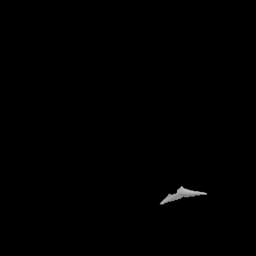

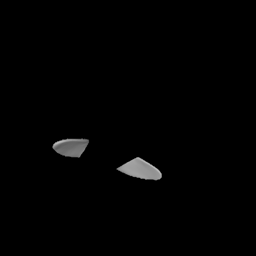

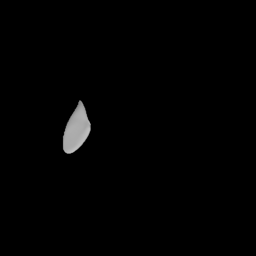

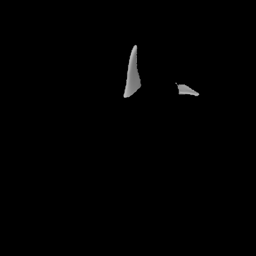

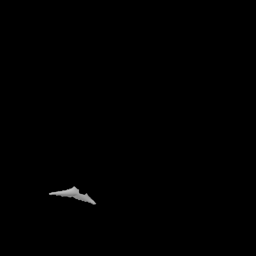

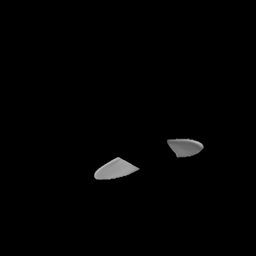

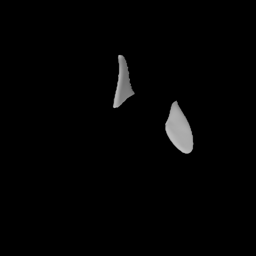

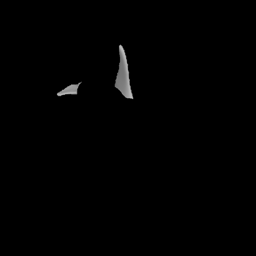

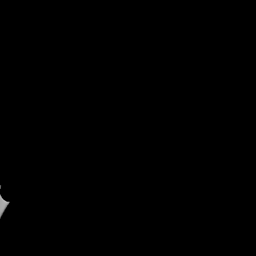

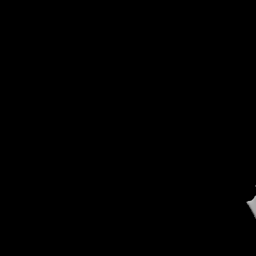

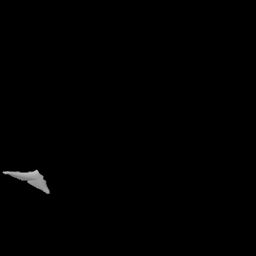

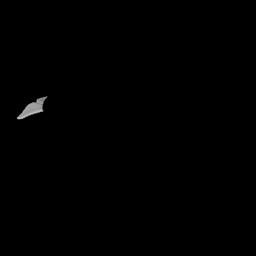

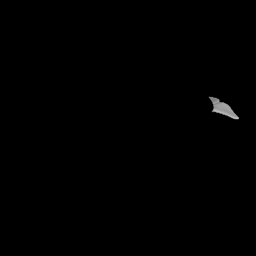

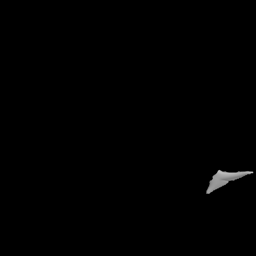

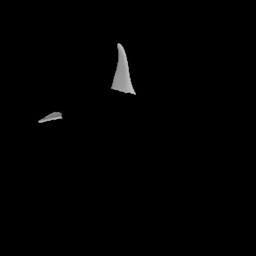

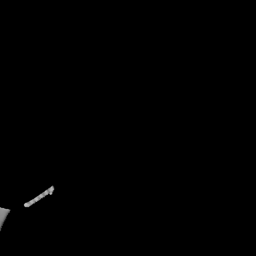

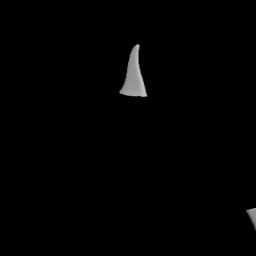

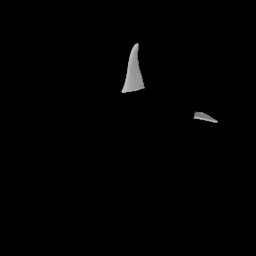

Prompt: Top fin


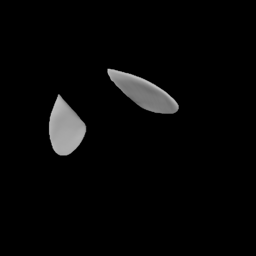

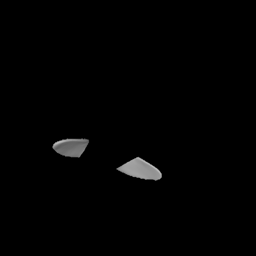

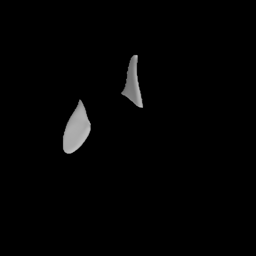

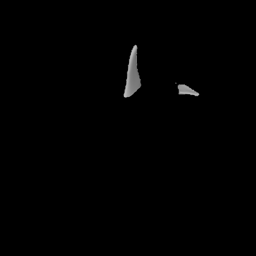

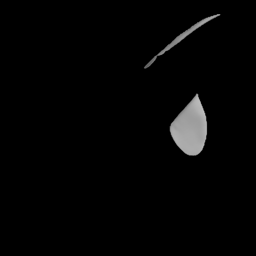

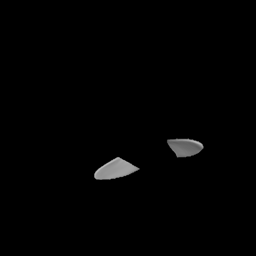

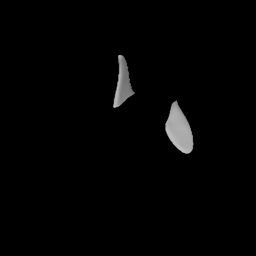

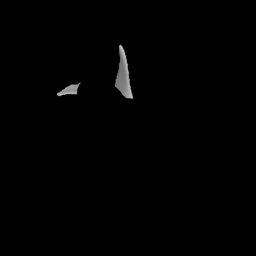

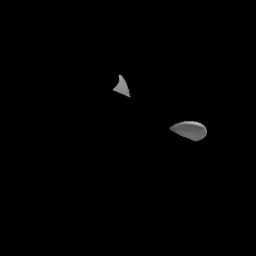

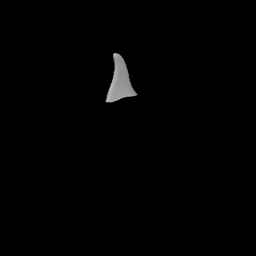

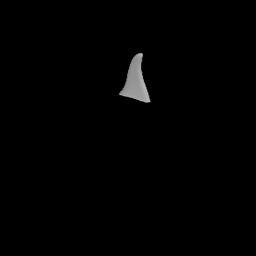

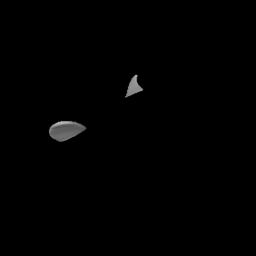

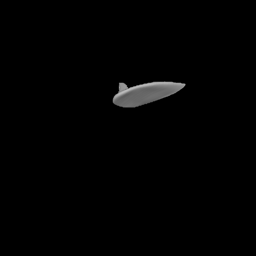

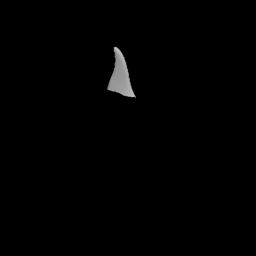

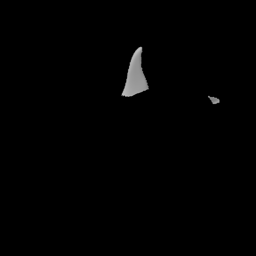

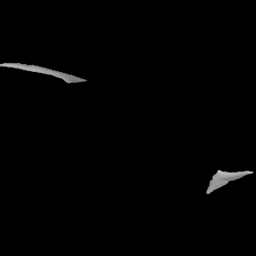

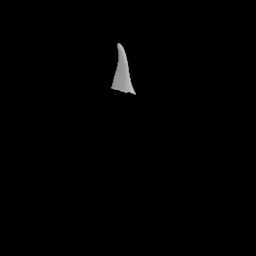

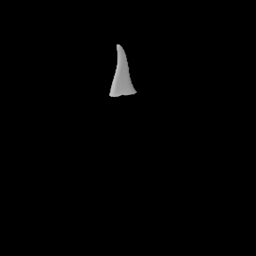

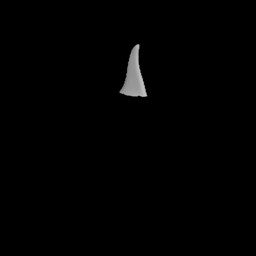

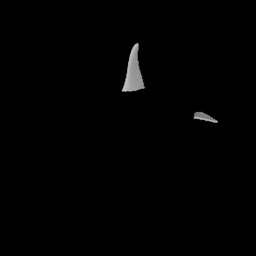

Prompt: Side fins


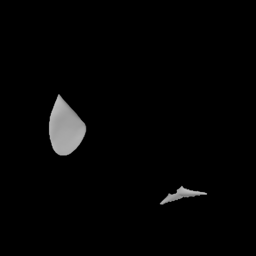

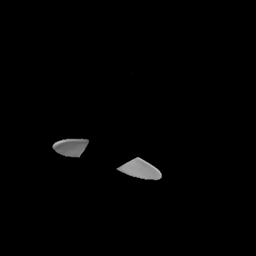

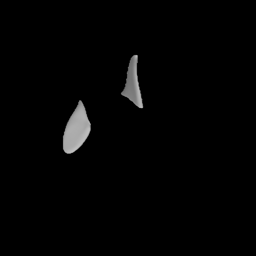

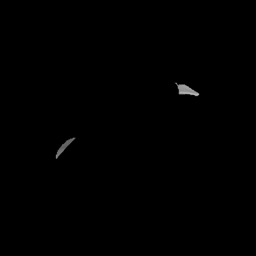

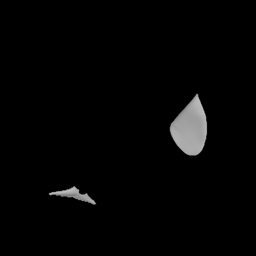

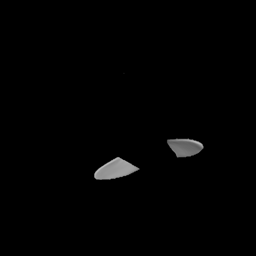

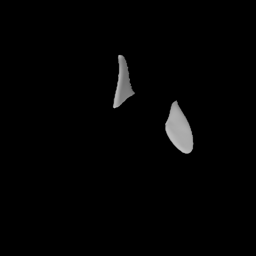

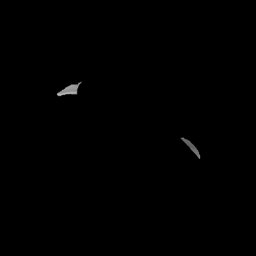

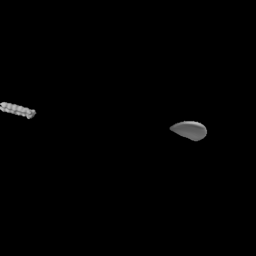

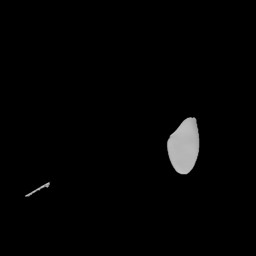

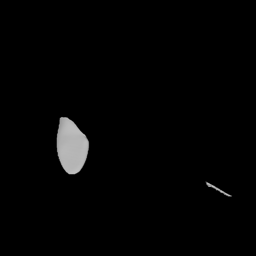

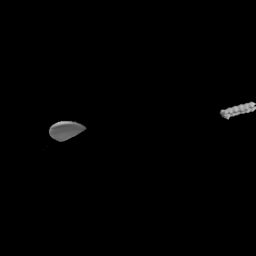

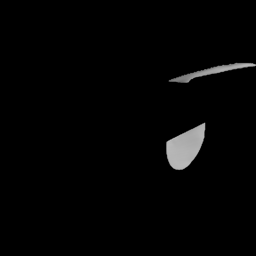

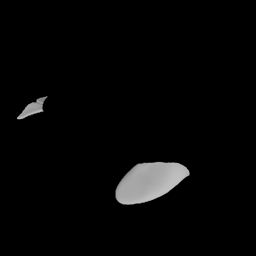

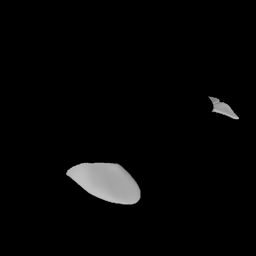

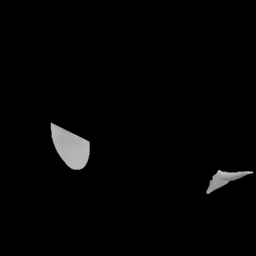

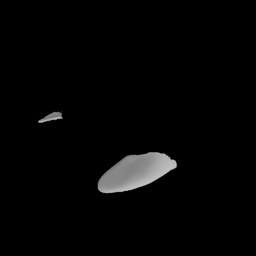

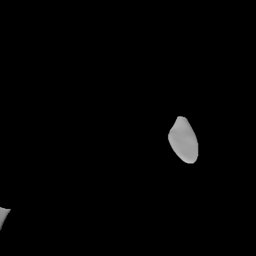

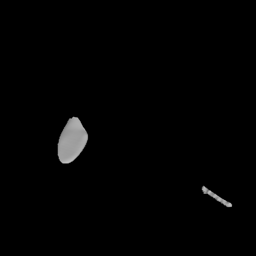

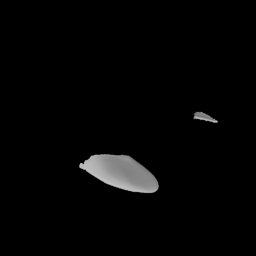

Prompt: Belly fins
Prompt: Bottom fin near tail


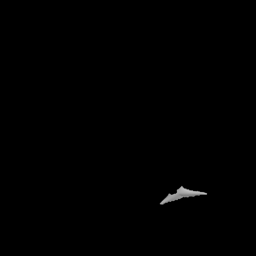

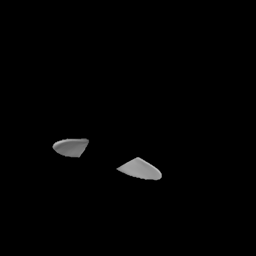

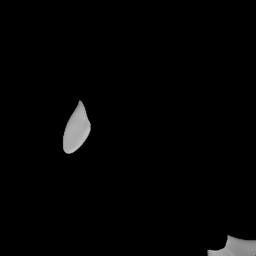

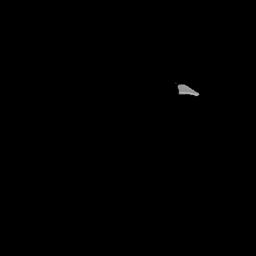

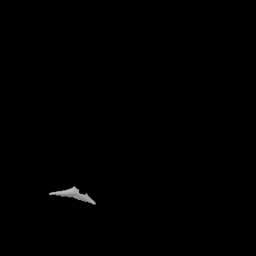

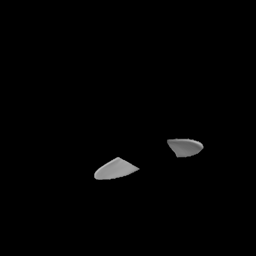

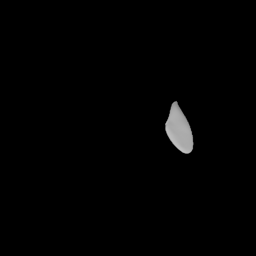

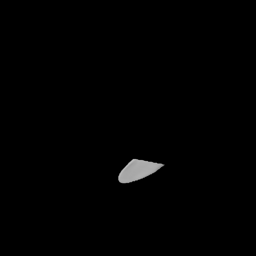

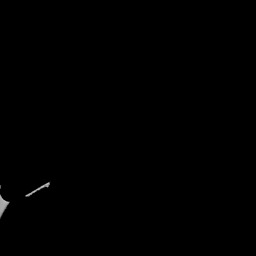

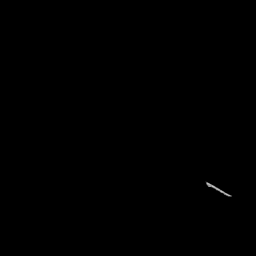

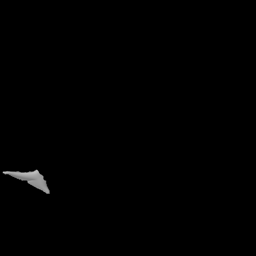

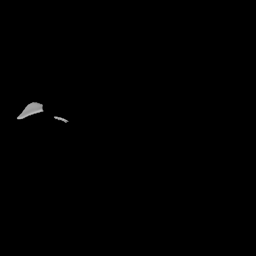

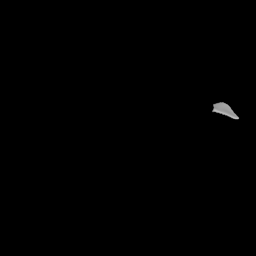

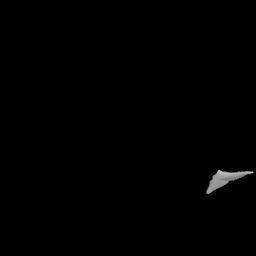

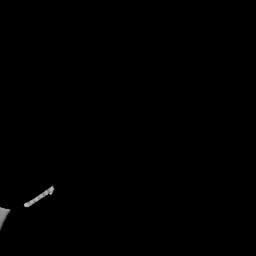

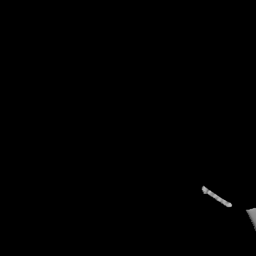

In [9]:
for prompt, results in results_dict.items():
    print("Prompt:", prompt)
    for result in results:
        mask = result["masks"]
        image = result["image"]

        if mask is None or not np.any(mask):
            continue

        if mask.shape != image.shape[:2]:
            mask = cv2.resize(
                mask.astype(np.uint8),
                (image.shape[1], image.shape[0]),
                interpolation=cv2.INTER_NEAREST,
            ).astype(bool)

        masked_image = np.zeros_like(image)
        for c in range(image.shape[2]):
            masked_image[:, :, c] = image[:, :, c] * mask

        masked_image_pil = Image.fromarray(masked_image)
        display(masked_image_pil.resize((masked_image_pil.width // 4, masked_image_pil.height // 4)))


### Release SAM3 from GPU Memory
Free GPU VRAM after completing 2D vision-language inference to avoid memory pressure during downstream 3D mesh processing.


In [10]:
if 'model' in globals():
    del model
if 'processor' in globals():
    del processor
if 'text_embeds_list' in globals():
    del text_embeds_list
if 'text_inputs_list' in globals():
    del text_inputs_list

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

print("SAM3 model released from GPU.")
if torch.cuda.is_available():
    print(f"Allocated VRAM: {torch.cuda.memory_allocated() / (1024 ** 2):.2f} MB")
    print(f"Reserved VRAM:  {torch.cuda.memory_reserved() / (1024 ** 2):.2f} MB")


SAM3 model released from GPU.
Allocated VRAM: 223.85 MB
Reserved VRAM:  310.00 MB


# 1. Multi-View Visibility & Detection Aggregation
Calculate multi-view face visibility ($V_{vis}(f)$) and accumulate prompt detection hits across all 20 camera viewports.


In [11]:
num_faces = len(mesh.mesh.faces)
face_visibility_count = np.zeros(num_faces, dtype=np.int32)
face_prompt_detected = {p: np.zeros(num_faces, dtype=np.int32) for p in prompts}

for view_idx in range(len(faces_per_view)):
    v_faces = faces_per_view[view_idx]
    visible_faces = np.unique(v_faces[v_faces >= 0])
    face_visibility_count[visible_faces] += 1
    
    for prompt in prompts:
        mask = results_dict[prompt][view_idx]["masks"]
        if mask is not None and np.any(mask):
            m_faces = v_faces[mask > 0]
            m_faces = m_faces[m_faces >= 0]
            detected_faces = np.unique(m_faces)
            face_prompt_detected[prompt][detected_faces] += 1

total_fin_detected = np.zeros(num_faces, dtype=np.int32)
for p in prompts:
    total_fin_detected += face_prompt_detected[p]

print(f"Total mesh faces: {num_faces}")
print(f"Faces with >= 1 detection: {(total_fin_detected >= 1).sum()}")
print(f"Faces with >= 2 detections: {(total_fin_detected >= 2).sum()}")


Total mesh faces: 231624
Faces with >= 1 detection: 60821
Faces with >= 2 detections: 54024


# 2. Three-Tier Blob Partitioning & k=3 KD-Tree Micro-Assignment

Candidate 3D blobs are categorized into three geometric tiers:
1. **Major Appendages ($\ge 2.5\%$ surface area)**: The primary anatomical anchors (Dorsal, Pectorals, Tail Fluke).
2. **False-Positive Body Blobs ($0.5\% - 2.5\%$ area)**: Moderate hallucinations on the body (e.g. snout patch) kept aside and removed from appendages.
3. **Small Micro-Blobs ($< 0.5\%$ area)**: Assigned to the closest major appendage using $k=3$ nearest-neighbor averaging via `cKDTree` if within attachment distance; distant stray noise is discarded.

In [12]:
from scipy.spatial import cKDTree

face_areas = triangle_areas(mesh.mesh.vertices, mesh.mesh.faces)
total_mesh_area = np.sum(face_areas)

adj = mesh.mesh.face_adjacency
adj_dict = defaultdict(list)
for f1, f2 in adj:
    adj_dict[f1].append(f2)
    adj_dict[f2].append(f1)

candidate_mask = total_fin_detected >= 2
visited = np.zeros(num_faces, dtype=bool)
raw_blobs = []

for f in np.where(candidate_mask)[0]:
    if visited[f]:
        continue
    comp = []
    queue = [f]
    visited[f] = True
    while queue:
        curr = queue.pop()
        comp.append(curr)
        for nb in adj_dict[curr]:
            if candidate_mask[nb] and not visited[nb]:
                visited[nb] = True
                queue.append(nb)
    raw_blobs.append(np.array(comp, dtype=np.int32))

raw_blobs.sort(key=lambda b: np.sum(face_areas[b]), reverse=True)

MAJOR_THRESHOLD = 0.025
MICRO_THRESHOLD = 0.005

major_blobs = []
false_positive_body_blobs = []
micro_blobs = []

for comp in raw_blobs:
    b_area = np.sum(face_areas[comp])
    ratio = b_area / total_mesh_area
    if ratio >= MAJOR_THRESHOLD:
        major_blobs.append(comp)
    elif ratio >= MICRO_THRESHOLD:
        false_positive_body_blobs.append(comp)
    else:
        micro_blobs.append(comp)

print(f"Extracted {len(raw_blobs)} candidate blobs:")
print(f"  Major Appendages: {len(major_blobs)}")
print(f"  False-Positive Body Blobs (Removed): {len(false_positive_body_blobs)}")
print(f"  Small Micro-Blobs: {len(micro_blobs)}")


Extracted 627 candidate blobs:
  Major Appendages: 4
  False-Positive Body Blobs (Removed): 2
  Small Micro-Blobs: 621


# 3. 3D Spatial & Anatomical Classification
Classify each major appendage into Top Fin (Dorsal), Left Pectoral Fin, Right Pectoral Fin, and Tail Fin (Caudal) using 3D coordinates and bilateral symmetry.


In [13]:
major_appendages = {}

for blob_faces in major_blobs:
    verts = np.unique(mesh.mesh.faces[blob_faces])
    centroid = mesh.mesh.vertices[verts].mean(axis=0)
    cx, cy, cz = centroid
    
    if cx > 0.60:
        label = "Tail Fin (Caudal)"
    elif cy > 0.15 and abs(cz) < 0.15:
        label = "Top Fin (Dorsal)"
    elif cz > 0.15:
        label = "Left Pectoral Fin"
    elif cz < -0.15:
        label = "Right Pectoral Fin"
    else:
        label = "Other Appendage"
        
    major_appendages[label] = {
        "faces": blob_faces,
        "centroid": centroid,
        "verts": verts,
        "kdtree": cKDTree(mesh.mesh.vertices[verts]),
        "area": np.sum(face_areas[blob_faces]),
    }

MAX_ATTACH_DISTANCE = 0.08
micro_absorbed_counts = defaultdict(int)
assigned_micro_faces = defaultdict(list)

for comp in micro_blobs:
    m_verts = np.unique(mesh.mesh.faces[comp])
    m_pts = mesh.mesh.vertices[m_verts]
    
    best_label = None
    min_k3_dist = float("inf")
    
    for label, major_data in major_appendages.items():
        dists, _ = major_data["kdtree"].query(m_pts, k=min(3, len(major_data["verts"])))
        mean_k3 = np.mean(dists)
        if mean_k3 < min_k3_dist:
            min_k3_dist = mean_k3
            best_label = label
            
    if min_k3_dist <= MAX_ATTACH_DISTANCE:
        assigned_micro_faces[best_label].extend(comp)
        micro_absorbed_counts[best_label] += len(comp)

for label, major_data in major_appendages.items():
    if len(assigned_micro_faces[label]) > 0:
        major_data["faces"] = np.concatenate([major_data["faces"], assigned_micro_faces[label]])
    print(f"Classified '{label:20s}': {len(major_data['faces']):5d} faces (absorbed {micro_absorbed_counts[label]} micro-faces)")


Classified 'Right Pectoral Fin  ': 16711 faces (absorbed 355 micro-faces)
Classified 'Left Pectoral Fin   ': 16123 faces (absorbed 82 micro-faces)
Classified 'Tail Fin (Caudal)   ': 10549 faces (absorbed 377 micro-faces)
Classified 'Top Fin (Dorsal)    ':  7413 faces (absorbed 37 micro-faces)


# 4. Root Hole Triangulation with `triangle` & GLB Export
Extract submeshes for each classified appendage and use the `triangle` library (Constrained Delaunay Triangulation) to cap the open boundary root loops where fins detached from the body.


In [ ]:
def cap_root_hole_with_triangle(submesh: trimesh.Trimesh) -> trimesh.Trimesh:
    submesh = submesh.copy()
    edges = submesh.faces[:, [0, 1, 1, 2, 2, 0]].reshape(-1, 2)
    edges_sorted = np.sort(edges, axis=1)
    unique_edges, unique_inverse, counts = np.unique(
        edges_sorted, axis=0, return_inverse=True, return_counts=True
    )
    boundary_edge_mask = counts[unique_inverse] == 1
    boundary_directed = edges[boundary_edge_mask]
    
    if len(boundary_directed) == 0:
        return submesh
        
    G = nx.DiGraph()
    for u, v in boundary_directed:
        G.add_edge(u, v)
        
    loops = [c for c in nx.simple_cycles(G) if len(c) >= 3]
    if not loops:
        return submesh
        
    all_verts = list(submesh.vertices)
    all_faces = list(submesh.faces)
    
    for loop_vert_indices in loops:
        loop_vert_indices = np.array(loop_vert_indices, dtype=np.int64)
        loop_pts_3d = submesh.vertices[loop_vert_indices]
        K = len(loop_pts_3d)
        if K < 3:
            continue
            
        centroid = loop_pts_3d.mean(axis=0)
        centered = loop_pts_3d - centroid
        _, _, vh = np.linalg.svd(centered)
        u1, u2 = vh[0], vh[1]
        normal = np.cross(u1, u2)
        norm_len = np.linalg.norm(normal)
        if norm_len > 1e-12:
            normal = normal / norm_len
            
        pts_2d = np.column_stack([np.dot(centered, u1), np.dot(centered, u2)])
        segments = np.column_stack([np.arange(K), np.roll(np.arange(K), -1)])
        
        try:
            tri_out = triangle.triangulate({'vertices': pts_2d, 'segments': segments}, 'p')
        except Exception:
            tri_out = triangle.triangulate({'vertices': pts_2d, 'segments': segments}, 'c')
            
        out_verts_2d = tri_out['vertices']
        out_triangles = tri_out['triangles']
        
        vert_map = {i: loop_vert_indices[i] for i in range(K)}
        for i in range(K, len(out_verts_2d)):
            p2 = out_verts_2d[i]
            v3d = centroid + p2[0] * u1 + p2[1] * u2
            vert_map[i] = len(all_verts)
            all_verts.append(v3d)
            
        for tri in out_triangles:
            mapped_tri = [vert_map[tri[0]], vert_map[tri[1]], vert_map[tri[2]]]
            p0 = all_verts[mapped_tri[0]]
            p1 = all_verts[mapped_tri[1]]
            p2 = all_verts[mapped_tri[2]]
            tri_norm = np.cross(p1 - p0, p2 - p0)
            if np.dot(tri_norm, normal) < 0:
                mapped_tri = [mapped_tri[0], mapped_tri[2], mapped_tri[1]]
            all_faces.append(mapped_tri)
            
    return trimesh.Trimesh(vertices=np.array(all_verts), faces=np.array(all_faces), process=True)

fin_face_indices = []
for label, data in major_appendages.items():
    fin_face_indices.extend(data["faces"])

body_faces = np.setdiff1d(np.arange(num_faces), np.array(fin_face_indices))
major_appendages["Main Body"] = {
    "faces": body_faces,
    "centroid": mesh.mesh.vertices[np.unique(mesh.mesh.faces[body_faces])].mean(axis=0),
    "area": np.sum(face_areas[body_faces]),
}

export_dir = Path("../generated_data/test_segmented/killer_whale")
export_dir.mkdir(parents=True, exist_ok=True)

PART_FILES = {
    "Main Body": "body.glb",
    "Top Fin (Dorsal)": "top_fins.glb",
    "Left Pectoral Fin": "left_pectoral_fin.glb",
    "Right Pectoral Fin": "right_pectoral_fin.glb",
    "Tail Fin (Caudal)": "tail.glb",
}

print("Exporting all submeshes with triangle root capping:")
for label, filename in PART_FILES.items():
    blob_faces = major_appendages[label]["faces"]
    subm = mesh.mesh.submesh([blob_faces], append=True)
    capped_subm = cap_root_hole_with_triangle(subm)
    out_path = export_dir / filename
    capped_subm.export(out_path)
    print(f"  {label:25s} -> {filename:22s} ({len(capped_subm.vertices)} verts, {len(capped_subm.faces)} faces)")


Exporting all submeshes with triangle root capping:


# 5. Interactive 3D Multi-Color Visualization
Display the colored 3D mesh highlighting each isolated anatomical appendage.


In [ ]:
COLOR_PALETTE = {
    "Main Body": [60, 75, 85, 255],
    "Top Fin (Dorsal)": [0, 229, 255, 255],
    "Left Pectoral Fin": [0, 230, 118, 255],
    "Right Pectoral Fin": [255, 214, 0, 255],
    "Tail Fin (Caudal)": [255, 23, 68, 255],
}

face_colors = np.zeros((num_faces, 4), dtype=np.uint8)
face_colors[:] = COLOR_PALETTE["Main Body"]

for label, data in major_appendages.items():
    color = COLOR_PALETTE.get(label, [255, 255, 255, 255])
    face_colors[data["faces"]] = color

colored_mesh = mesh.mesh.copy()
colored_mesh.visual.face_colors = face_colors
colored_mesh.show()


### Final GPU & Memory Cleanup

Clear all remaining cache and memory references.

In [ ]:
if 'model' in globals():
    del model
if 'processor' in globals():
    del processor
if 'text_embeds_list' in globals():
    del text_embeds_list
if 'text_inputs_list' in globals():
    del text_inputs_list

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

print("Final memory cleanup complete.")
if torch.cuda.is_available():
    print(f"Allocated VRAM: {torch.cuda.memory_allocated() / (1024 ** 2):.2f} MB")
    print(f"Reserved VRAM:  {torch.cuda.memory_reserved() / (1024 ** 2):.2f} MB")
